In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB05\garments_worker_productivity.csv")
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe(include="all"))

Dataset Shape: (1197, 15)

Columns:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

First 5 Rows:


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382



Data Types:
date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object

Missing Values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

Summary Stat

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197,1197,1197,1197,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
unique,59,5,3,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1/31/2015,Quarter1,sweing,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,360,691,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,NaN,NaN,NaN,NaN,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,NaN,NaN,NaN,NaN,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,NaN,NaN,NaN,NaN,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,NaN,NaN,NaN,NaN,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,NaN,NaN,NaN,NaN,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253


In [18]:
target = "actual_productivity"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("Target data type:", y.dtype)
print("\nTarget statistics:")
print(y.describe())

print("\nMissing target values:", y.isnull().sum())

X shape: (1197, 14)
y shape: (1197,)

Features:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Target:
actual_productivity
Target data type: float64

Target statistics:
count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

Missing target values: 0


In [20]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})

missing_table = missing_table[missing_table["Missing Values"] > 0]
missing_table = missing_table.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_table)

Categorical features:
['date', 'quarter', 'department', 'day']

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Number of categorical features: 4
Number of numerical features: 10


C:\Users\HP\AppData\Local\Temp\ipykernel_22604\1424160945.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


,Missing Values,Missing Percentage
wip,506,42.272348


In [21]:
for col in categorical_features:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print("Number of unique values:", df[col].nunique())
    print("\nValue counts:")
    print(df[col].value_counts(dropna=False))


date
Number of unique values: 59

Value counts:
date
1/31/2015    24
3/11/2015    24
1/11/2015    23
1/12/2015    23
1/24/2015    23
3/10/2015    23
1/5/2015     22
1/7/2015     22
1/8/2015     22
1/10/2015    22
1/13/2015    22
1/22/2015    22
3/3/2015     22
3/8/2015     22
3/9/2015     22
1/3/2015     21
1/4/2015     21
1/6/2015     21
1/14/2015    21
1/17/2015    21
1/25/2015    21
1/27/2015    21
1/28/2015    21
2/18/2015    21
2/25/2015    21
2/26/2015    21
2/28/2015    21
3/4/2015     21
1/29/2015    20
2/17/2015    20
2/19/2015    20
2/22/2015    20
3/1/2015     20
3/2/2015     20
1/1/2015     19
1/15/2015    19
1/18/2015    19
1/19/2015    19
1/21/2015    19
1/26/2015    19
2/1/2015     19
2/2/2015     19
2/3/2015     19
2/4/2015     19
2/7/2015     19
2/8/2015     19
2/10/2015    19
2/11/2015    19
2/12/2015    19
2/15/2015    19
2/23/2015    19
2/24/2015    19
3/5/2015     19
3/7/2015     19
2/5/2015     18
2/9/2015     18
2/16/2015    18
2/14/2015    17
1/20/2015    15
Na

In [22]:
display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.00,3.00,6.00,9.00,12.00
targeted_productivity,1197.0,0.729632,0.097891,0.07,0.70,0.75,0.80,0.80
smv,1197.0,15.062172,10.943219,2.90,3.94,15.26,24.26,54.56
wip,691.0,1190.465991,1837.455001,7.00,774.50,1039.00,1252.50,23122.00
over_time,1197.0,4567.460317,3348.823563,0.00,1440.00,3960.00,6960.00,25920.00
incentive,1197.0,38.210526,160.182643,0.00,0.00,0.00,50.00,3600.00
idle_time,1197.0,0.730159,12.709757,0.00,0.00,0.00,0.00,300.00
idle_men,1197.0,0.369256,3.268987,0.00,0.00,0.00,0.00,45.00
no_of_style_change,1197.0,0.150376,0.427848,0.00,0.00,0.00,0.00,2.00
no_of_workers,1197.0,34.609858,22.197687,2.00,9.00,34.00,57.00,89.00


In [23]:
print("Target statistics:")
print(y.describe())

print("\nTarget skewness:", y.skew())
print("Target kurtosis:", y.kurtosis())

Target statistics:
count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

Target skewness: -0.8074917745097576
Target kurtosis: 0.33322734124329134


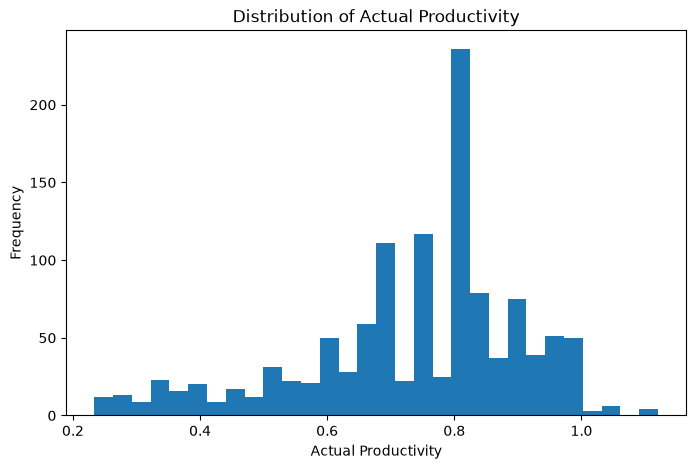

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Productivity")
plt.show()

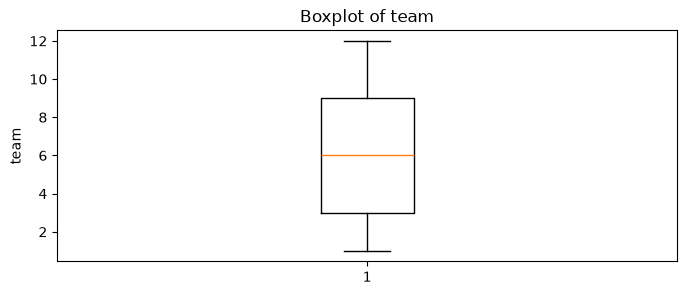

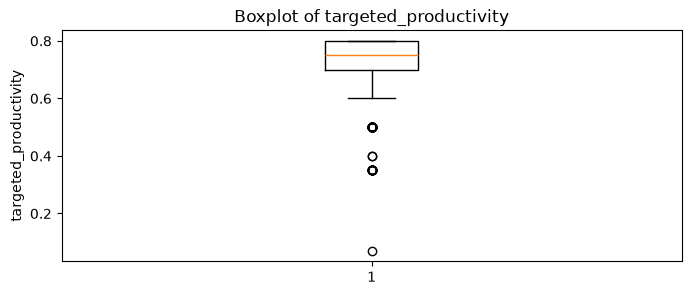

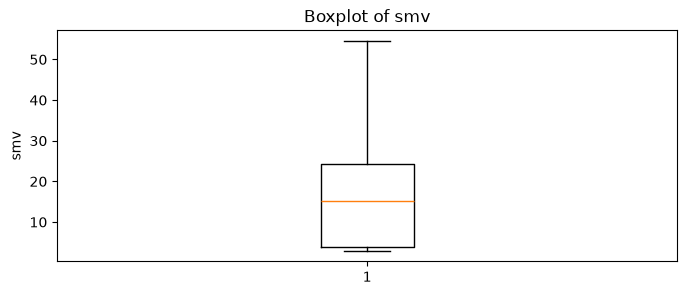

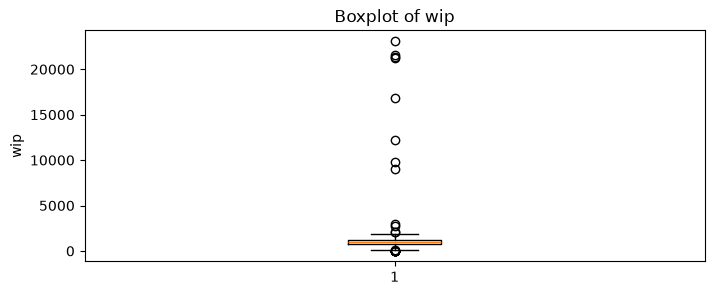

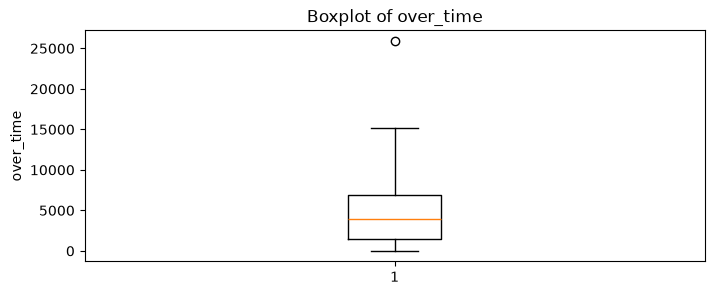

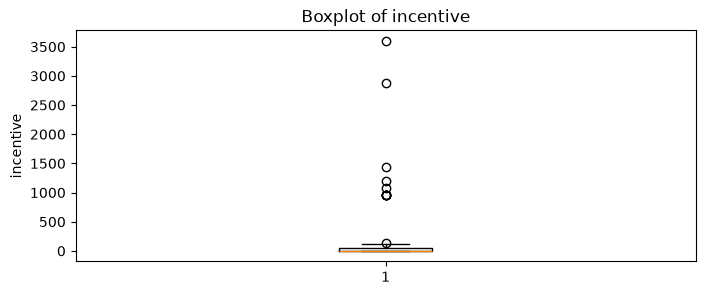

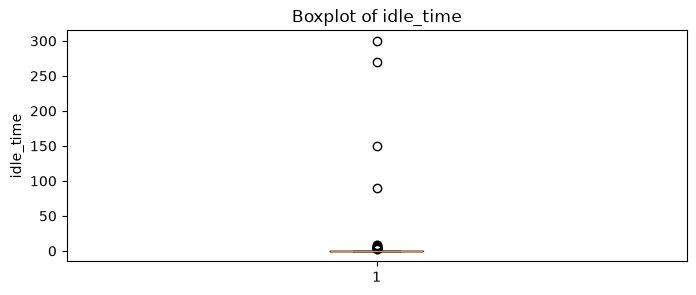

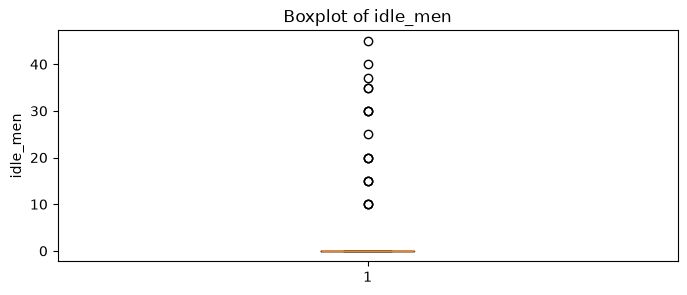

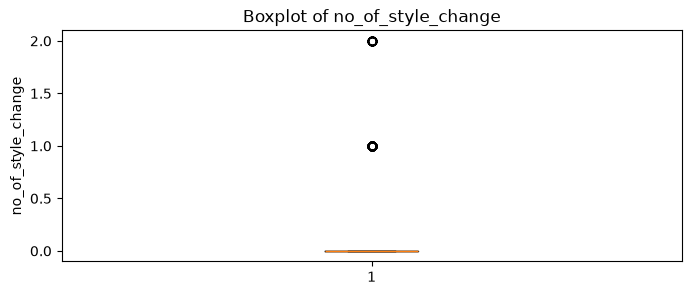

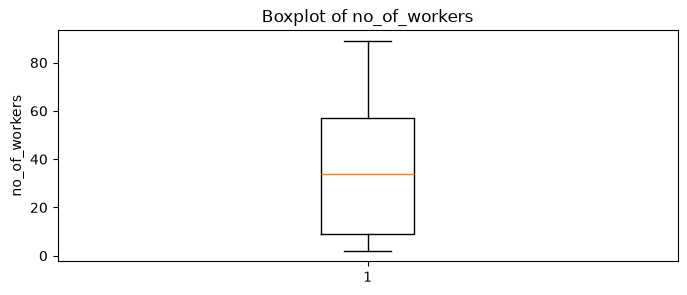

In [25]:
for col in numerical_features:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [26]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [27]:
print("Date dtype:", df["date"].dtype)

print("\nNumber of unique dates:", df["date"].nunique())

print("\nFirst 10 dates:")
print(df["date"].head(10))

print("\nLast 10 dates:")
print(df["date"].tail(10))

Date dtype: str

Number of unique dates: 59

First 10 dates:
0    1/1/2015
1    1/1/2015
2    1/1/2015
3    1/1/2015
4    1/1/2015
5    1/1/2015
6    1/1/2015
7    1/1/2015
8    1/1/2015
9    1/1/2015
Name: date, dtype: str

Last 10 dates:
1187    3/11/2015
1188    3/11/2015
1189    3/11/2015
1190    3/11/2015
1191    3/11/2015
1192    3/11/2015
1193    3/11/2015
1194    3/11/2015
1195    3/11/2015
1196    3/11/2015
Name: date, dtype: str


In [39]:
print(df.columns.tolist())

['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'month', 'day_of_month']


In [40]:
# Check whether date features already exist
if "month" not in df.columns or "day_of_month" not in df.columns:
    print("Date features are missing.")
    print("We need to recreate them from the original dataset.")
else:
    print("Date features already exist.")

print("\nCurrent columns:")
print(df.columns.tolist())

Date features already exist.

Current columns:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'month', 'day_of_month']


In [41]:
target = "actual_productivity"

X = df.drop(columns=[target])
y = df[target]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

X shape: (1197, 15)
y shape: (1197,)

Categorical features:
['quarter', 'department', 'day']

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


C:\Users\HP\AppData\Local\Temp\ipykernel_22604\858870436.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['team', 'targeted_productivity', 'smv', 'wip',
                                  'over_time', 'incentive', 'idle_time',
                                  'idle_men', 'no_of_style_change',
                                  'no_of_workers']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['quarter', 'department', 'day'])])


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (957, 15)
y_train: (957,)

Testing data:
X_test: (240, 15)
y_test: (240,)


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['quarter','department','day',...,'no_of_workers','month','day_of_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [48]:
predictions = rf_pipeline.predict(X_test)

print("Number of predictions:", len(predictions))
print("First 10 predictions:")
print(predictions[:10])

Number of predictions: 240
First 10 predictions:
[0.47650549 0.80009698 0.64454096 0.56002427 0.59815636 0.72370228
 0.58083321 0.53971467 0.62736813 0.74880946]


In [49]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Random Forest Results")
print("-" * 40)
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")

Random Forest Results
----------------------------------------
MSE  : 0.011775
RMSE : 0.108514
MAE  : 0.068484
R²   : 0.556528


In [50]:
residuals = y_test - predictions

print("First 10 residuals:")
print(residuals.head(10))

print("\nResidual statistics:")
print("Mean residual:", residuals.mean())
print("Minimum residual:", residuals.min())
print("Maximum residual:", residuals.max())

First 10 residuals:
921    -0.208291
321     0.000262
101     0.036520
920    -0.235024
58      0.069448
790     0.077278
948     0.188014
969     0.229133
410     0.023049
1079    0.001586
Name: actual_productivity, dtype: float64

Residual statistics:
Mean residual: 0.011318483486603914
Minimum residual: -0.5420810839949993
Maximum residual: 0.42320393463499945


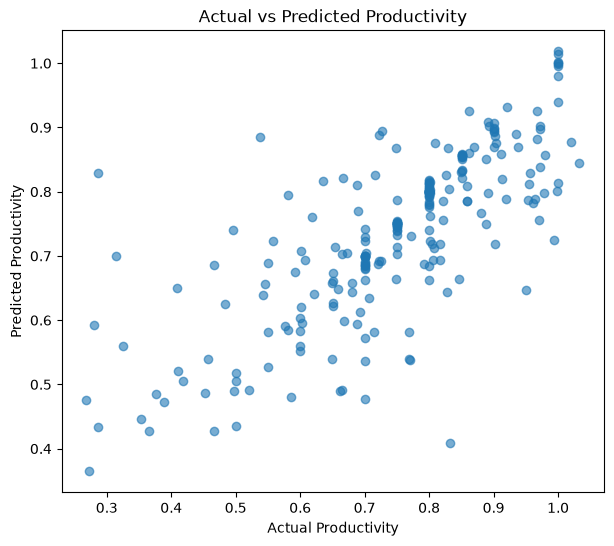

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity")

plt.show()

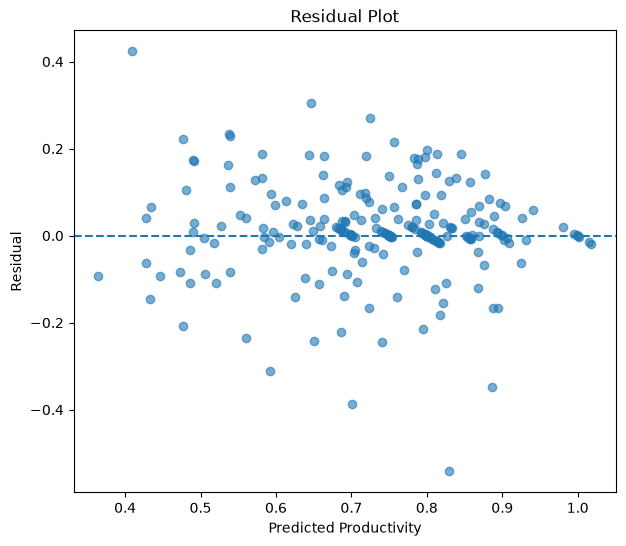

In [52]:
plt.figure(figsize=(7, 6))

plt.scatter(predictions, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Productivity")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [55]:
from sklearn.linear_model import LinearRegression
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['quarter','department','day',...,'no_of_workers','month','day_of_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [56]:
linear_predictions = linear_pipeline.predict(X_test)

print("Number of predictions:", len(linear_predictions))
print("First 10 predictions:")
print(linear_predictions[:10])

Number of predictions: 240
First 10 predictions:
[0.62391331 0.77049036 0.82839304 0.73502695 0.81634848 0.7970484
 0.55019273 0.58497438 0.69604611 0.75161953]


In [57]:
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

print("\nLinear Regression Results")
print("-" * 40)
print(f"MSE  : {linear_mse:.6f}")
print(f"RMSE : {linear_rmse:.6f}")
print(f"MAE  : {linear_mae:.6f}")
print(f"R²   : {linear_r2:.6f}")


Linear Regression Results
----------------------------------------
MSE  : 0.022087
RMSE : 0.148618
MAE  : 0.108453
R²   : 0.168168


In [60]:
from sklearn.ensemble import GradientBoostingRegressor
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", GradientBoostingRegressor(random_state=42))
    ]
)
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['quarter','department','day',...,'no_of_workers','month','day_of_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [61]:
gb_pipeline.fit(X_train, y_train)
gb_predictions = gb_pipeline.predict(X_test)

print("Number of predictions:", len(gb_predictions))
print("First 10 predictions:")
print(gb_predictions[:10])

Number of predictions: 240
First 10 predictions:
[0.49869452 0.8085557  0.69396236 0.5824066  0.66183251 0.72044514
 0.42439956 0.43189587 0.65207344 0.75054835]


In [62]:
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("\nGradient Boosting Results")
print("-" * 40)
print(f"MSE  : {gb_mse:.6f}")
print(f"RMSE : {gb_rmse:.6f}")
print(f"MAE  : {gb_mae:.6f}")
print(f"R²   : {gb_r2:.6f}")


Gradient Boosting Results
----------------------------------------
MSE  : 0.014237
RMSE : 0.119321
MAE  : 0.076722
R²   : 0.463801


In [64]:
from sklearn.ensemble import ExtraTreesRegressor
extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_pipeline.fit(X_train, y_train)
extra_predictions = extra_pipeline.predict(X_test)

print("Number of predictions:", len(extra_predictions))
print("First 10 predictions:")
print(extra_predictions[:10])

Number of predictions: 240
First 10 predictions:
[0.50053329 0.79842943 0.64259492 0.57128889 0.62414426 0.76538545
 0.7021684  0.64759946 0.62546599 0.72831318]


In [65]:
extra_mse = mean_squared_error(y_test, extra_predictions)
extra_rmse = np.sqrt(extra_mse)
extra_mae = mean_absolute_error(y_test, extra_predictions)
extra_r2 = r2_score(y_test, extra_predictions)

print("\nExtra Trees Results")
print("-" * 40)
print(f"MSE  : {extra_mse:.6f}")
print(f"RMSE : {extra_rmse:.6f}")
print(f"MAE  : {extra_mae:.6f}")
print(f"R²   : {extra_r2:.6f}")


Extra Trees Results
----------------------------------------
MSE  : 0.014649
RMSE : 0.121032
MAE  : 0.075473
R²   : 0.448310


In [66]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Boosting",
        "Extra Trees",
        "Random Forest"
    ],
    "MSE": [
        linear_mse,
        gb_mse,
        extra_mse,
        mse
    ],
    "RMSE": [
        linear_rmse,
        gb_rmse,
        extra_rmse,
        rmse
    ],
    "MAE": [
        linear_mae,
        gb_mae,
        extra_mae,
        mae
    ],
    "R2": [
        linear_r2,
        gb_r2,
        extra_r2,
        r2
    ]
})

comparison

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.022087,0.148618,0.108453,0.168168
1,Gradient Boosting,0.014237,0.119321,0.076722,0.463801
2,Extra Trees,0.014649,0.121032,0.075473,0.448310
3,Random Forest,0.011775,0.108514,0.068484,0.556528


In [67]:
comparison_sorted = comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_sorted

,Model,MSE,RMSE,MAE,R2
0,Random Forest,0.011775,0.108514,0.068484,0.556528
1,Gradient Boosting,0.014237,0.119321,0.076722,0.463801
2,Extra Trees,0.014649,0.121032,0.075473,0.448310
3,Linear Regression,0.022087,0.148618,0.108453,0.168168


In [68]:
comparison_rmse = comparison.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

comparison_rmse

,Model,MSE,RMSE,MAE,R2
0,Random Forest,0.011775,0.108514,0.068484,0.556528
1,Gradient Boosting,0.014237,0.119321,0.076722,0.463801
2,Extra Trees,0.014649,0.121032,0.075473,0.448310
3,Linear Regression,0.022087,0.148618,0.108453,0.168168


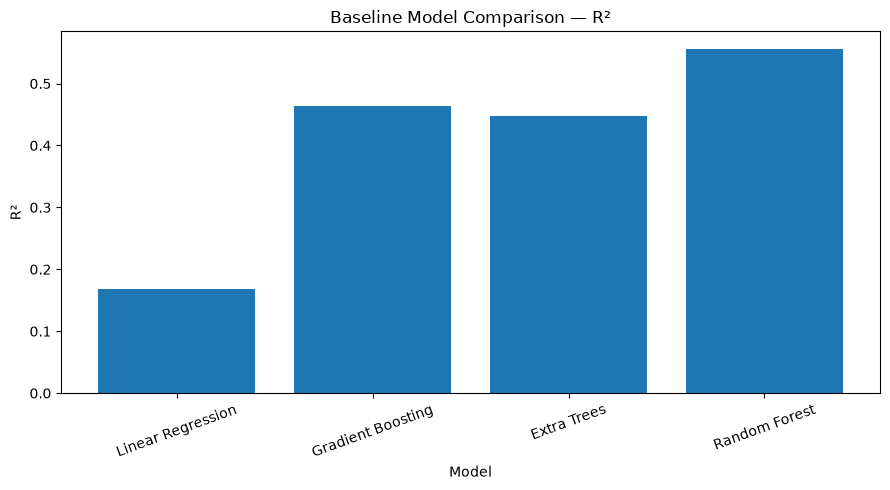

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(comparison["Model"], comparison["R2"])

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("Baseline Model Comparison — R²")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

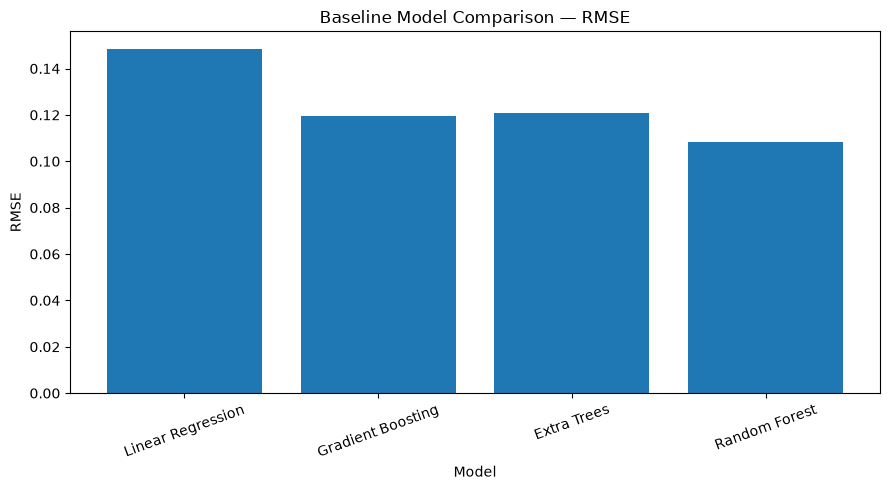

In [70]:
plt.figure(figsize=(9, 5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Baseline Model Comparison — RMSE")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [77]:
df_eng = pd.read_csv(r"C:\Users\HP\Documents\DS605-Fundamentals-of-Machine-Learning\LAB05\garments_worker_productivity.csv")
print(df_eng.shape)
print(df_eng.columns.tolist())
df_eng["date"] = pd.to_datetime(df_eng["date"])
print(df_eng["date"].dtype)
print(df_eng["date"].head())

(1197, 15)
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']
datetime64[us]
0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: date, dtype: datetime64[us]


In [78]:
df_eng["month"] = df_eng["date"].dt.month
df_eng["day_of_month"] = df_eng["date"].dt.day
print(
    df_eng[
        ["date", "month", "day_of_month"]
    ].head()
)

        date  month  day_of_month
0 2015-01-01      1             1
1 2015-01-01      1             1
2 2015-01-01      1             1
3 2015-01-01      1             1
4 2015-01-01      1             1


In [79]:
df_eng = df_eng.drop(columns=["date"])
print(df_eng.columns.tolist())
print(df_eng.shape)

['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'month', 'day_of_month']
(1197, 16)


In [80]:
X_eng = df_eng.drop(columns=["actual_productivity"])
y_eng = df_eng["actual_productivity"]

print("X_eng shape:", X_eng.shape)
print("y_eng shape:", y_eng.shape)

print("\nFeatures:")
print(X_eng.columns.tolist())

X_eng shape: (1197, 15)
y_eng shape: (1197,)

Features:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'month', 'day_of_month']


In [82]:
from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng,
    y_eng,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train_eng:", X_train_eng.shape)
print("y_train_eng:", y_train_eng.shape)

print("\nTesting data:")
print("X_test_eng:", X_test_eng.shape)
print("y_test_eng:", y_test_eng.shape)

Training data:
X_train_eng: (957, 15)
y_train_eng: (957,)

Testing data:
X_test_eng: (240, 15)
y_test_eng: (240,)


In [83]:
print("Engineered training columns:")
print(X_train_eng.columns.tolist())

Engineered training columns:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'month', 'day_of_month']


In [87]:
numerical_features_eng = [
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "month",
    "day_of_month"
]

categorical_features_eng = [
    "quarter",
    "department",
    "day"
]


In [92]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
numeric_transformer_eng = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_eng = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_eng = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_eng,
            numerical_features_eng
        ),
        (
            "cat",
            categorical_transformer_eng,
            categorical_features_eng
        )
    ]
)

preprocessor_eng

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [93]:
print("Numerical features:")
print(numerical_features_eng)

print("\nNumber of numerical features:")
print(len(numerical_features_eng))

print("\nCategorical features:")
print(categorical_features_eng)

print("\nNumber of categorical features:")
print(len(categorical_features_eng))

print("\nTotal:")
print(
    len(numerical_features_eng)
    + len(categorical_features_eng)
)

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'month', 'day_of_month']

Number of numerical features:
12

Categorical features:
['quarter', 'department', 'day']

Number of categorical features:
3

Total:
15


In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline_eng = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline_eng.fit(X_train_eng, y_train_eng)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['quarter','department','day',...,'no_of_workers','month','day_of_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [99]:
final_predictions_eng = rf_pipeline_eng.predict(X_test_eng)

print("Number of predictions:", len(final_predictions_eng))

print("\nFirst 10 predictions:")
print(final_predictions_eng[:10])

Number of predictions: 240

First 10 predictions:
[0.46902662 0.80026357 0.65388586 0.56350467 0.64135911 0.71931968
 0.60012326 0.57661074 0.63337497 0.74826945]


In [101]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

final_mse_eng = mean_squared_error(
    y_test_eng,
    final_predictions_eng
)

final_rmse_eng = np.sqrt(final_mse_eng)

final_mae_eng = mean_absolute_error(
    y_test_eng,
    final_predictions_eng
)

final_r2_eng = r2_score(
    y_test_eng,
    final_predictions_eng
)

print("Engineered Random Forest Results")
print("-" * 45)
print(f"MSE  : {final_mse_eng:.6f}")
print(f"RMSE : {final_rmse_eng:.6f}")
print(f"MAE  : {final_mae_eng:.6f}")
print(f"R²   : {final_r2_eng:.6f}")

Engineered Random Forest Results
---------------------------------------------
MSE  : 0.011339
RMSE : 0.106486
MAE  : 0.068273
R²   : 0.572948


In [102]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Engineered Random Forest"
    ],
    "MSE": [
        mse,
        final_mse_eng
    ],
    "RMSE": [
        rmse,
        final_rmse_eng
    ],
    "MAE": [
        mae,
        final_mae_eng
    ],
    "R2": [
        r2,
        final_r2_eng
    ]
})

rf_comparison

,Model,MSE,RMSE,MAE,R2
0,Random Forest,0.011775,0.108514,0.068484,0.556528
1,Engineered Random Forest,0.011339,0.106486,0.068273,0.572948


In [103]:
rmse_improvement = (
    (rmse - final_rmse_eng) / rmse
) * 100

print(f"RMSE improvement: {rmse_improvement:.2f}%")

RMSE improvement: 1.87%


In [104]:
mae_improvement = (
    (mae - final_mae_eng) / mae
) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")

MAE improvement: 0.31%


In [105]:
r2_improvement = (
    (final_r2_eng - r2) / r2
) * 100

print(f"Relative R² improvement: {r2_improvement:.2f}%")

Relative R² improvement: 2.95%


In [106]:
print("Random Forest Comparison")
print("=" * 55)

print(f"{'Metric':<10} {'Baseline RF':>15} {'Engineered RF':>18}")
print("-" * 55)

print(f"{'MSE':<10} {mse:>15.6f} {final_mse_eng:>18.6f}")
print(f"{'RMSE':<10} {rmse:>15.6f} {final_rmse_eng:>18.6f}")
print(f"{'MAE':<10} {mae:>15.6f} {final_mae_eng:>18.6f}")
print(f"{'R²':<10} {r2:>15.6f} {final_r2_eng:>18.6f}")

print("\nImprovements")
print("-" * 55)
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"R² improvement  : {r2_improvement:.2f}%")

Random Forest Comparison
Metric         Baseline RF      Engineered RF
-------------------------------------------------------
MSE               0.011775           0.011339
RMSE              0.108514           0.106486
MAE               0.068484           0.068273
R²                0.556528           0.572948

Improvements
-------------------------------------------------------
RMSE improvement: 1.87%
MAE improvement : 0.31%
R² improvement  : 2.95%


In [107]:
eng_residuals = y_test_eng - final_predictions_eng

print("First 10 residuals:")
print(eng_residuals.head(10))

print("\nResidual statistics:")
print("Mean Residual:", eng_residuals.mean())
print("Minimum Residual:", eng_residuals.min())
print("Maximum Residual:", eng_residuals.max())

First 10 residuals:
921    -0.200812
321     0.000095
101     0.027175
920    -0.238505
58      0.026245
790     0.081661
948     0.168724
969     0.192236
410     0.017042
1079    0.002126
Name: actual_productivity, dtype: float64

Residual statistics:
Mean Residual: 0.011810051721937215
Minimum Residual: -0.5374953193249995
Maximum Residual: 0.3557579049250001


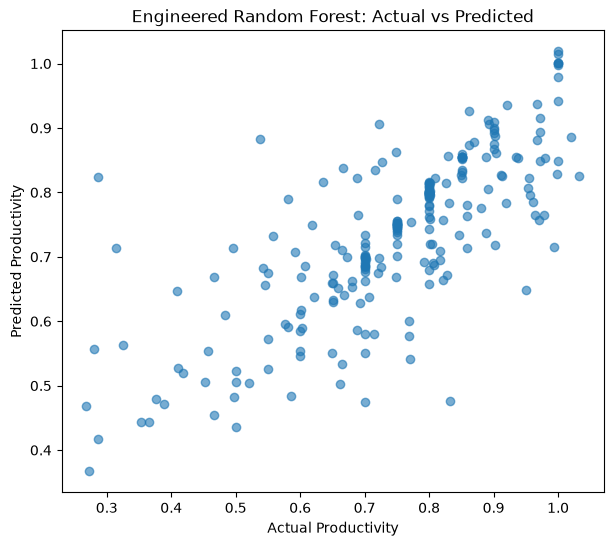

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_eng,
    final_predictions_eng,
    alpha=0.6
)

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Engineered Random Forest: Actual vs Predicted")

plt.show()

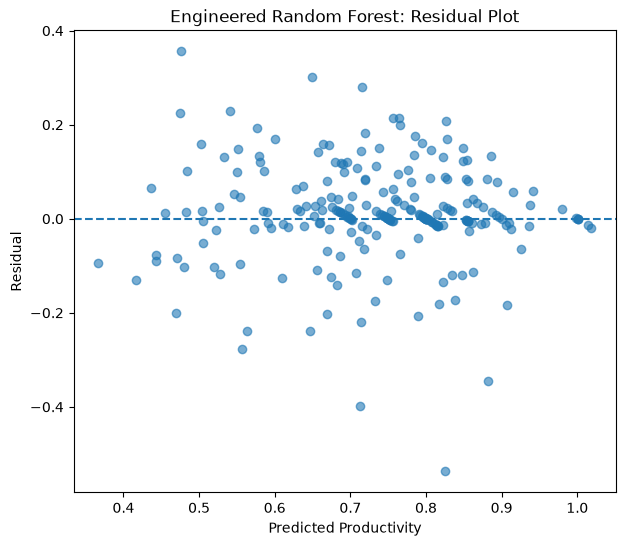

In [109]:
plt.figure(figsize=(7, 6))

plt.scatter(
    final_predictions_eng,
    eng_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Productivity")
plt.ylabel("Residual")
plt.title("Engineered Random Forest: Residual Plot")

plt.show()

In [111]:
error_analysis = pd.DataFrame({
    "Actual": y_test_eng.values,
    "Predicted": final_predictions_eng,
    "Residual": eng_residuals.values
})

error_analysis["Absolute_Error"] = (
    error_analysis["Residual"].abs()
)

largest_errors = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual,Predicted,Residual,Absolute_Error
206,0.287042,0.824537,-0.537495,0.537495
151,0.313853,0.713085,-0.399233,0.399233
54,0.831937,0.476180,0.355758,0.355758
29,0.537500,0.882378,-0.344878,0.344878
237,0.950625,0.648634,0.301991,0.301991
26,0.994375,0.715081,0.279294,0.279294
170,0.280333,0.556408,-0.276075,0.276075
3,0.325000,0.563505,-0.238505,0.238505
234,0.408960,0.646995,-0.238034,0.238034
164,0.770114,0.540835,0.229279,0.229279


In [114]:
rf_model_eng = rf_pipeline_eng.named_steps["regressor"]
rf_model_eng

feature_names_eng = (
    rf_pipeline_eng
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names_eng))
print("\nFirst 20 features:")
print(feature_names_eng[:20])

Number of transformed features: 26

First 20 features:
['num__team' 'num__targeted_productivity' 'num__smv' 'num__wip'
 'num__over_time' 'num__incentive' 'num__idle_time' 'num__idle_men'
 'num__no_of_style_change' 'num__no_of_workers' 'num__month'
 'num__day_of_month' 'cat__quarter_Quarter1' 'cat__quarter_Quarter2'
 'cat__quarter_Quarter3' 'cat__quarter_Quarter4' 'cat__quarter_Quarter5'
 'cat__department_finishing' 'cat__department_finishing '
 'cat__department_sweing']


In [115]:
importances_eng = rf_model_eng.feature_importances_
print("Number of feature names:", len(feature_names_eng))
print("Number of importances:", len(importances_eng))

Number of feature names: 26
Number of importances: 26


In [116]:
feature_importance_eng = pd.DataFrame({
    "Feature": feature_names_eng,
    "Importance": importances_eng
})

feature_importance_eng = feature_importance_eng.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_eng.head(15)

,Feature,Importance
0,num__targeted_productivity,0.234293
1,num__smv,0.106269
2,num__incentive,0.099164
3,num__team,0.093109
4,num__no_of_workers,0.087624
5,num__day_of_month,0.081604
6,num__over_time,0.070526
7,num__wip,0.034393
8,cat__department_finishing,0.025457
9,cat__quarter_Quarter4,0.016537


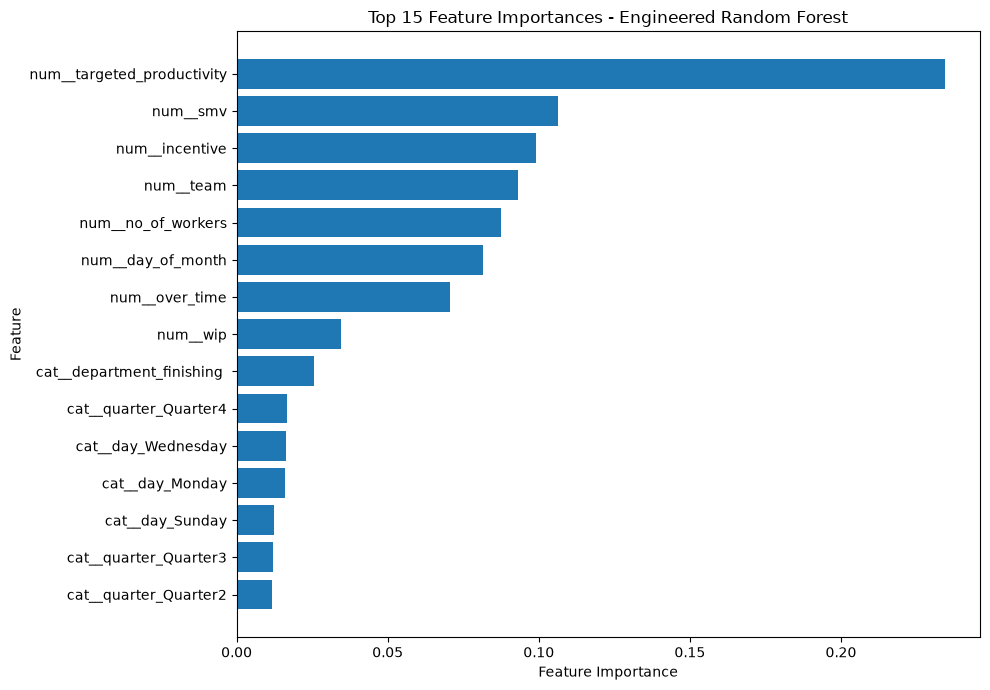

In [117]:
import matplotlib.pyplot as plt

top_features = feature_importance_eng.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Engineered Random Forest")

plt.tight_layout()
plt.show()

In [118]:
feature_importance_eng.to_csv(
    "engineered_random_forest_feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


In [119]:
engineered_features_importance = feature_importance_eng[
    feature_importance_eng["Feature"].str.contains(
        "month|day_of_month",
        case=False,
        regex=True
    )
]

engineered_features_importance

,Feature,Importance
5,num__day_of_month,0.081604
16,num__month,0.010172


In [120]:
for _, row in engineered_features_importance.iterrows():
    print(
        f"{row['Feature']}: "
        f"{row['Importance']:.6f}"
    )

num__day_of_month: 0.081604
num__month: 0.010172


In [121]:
combined_engineered_importance = (
    engineered_features_importance["Importance"].sum()
)

print(
    f"Combined importance of engineered date features: "
    f"{combined_engineered_importance:.6f}"
)

Combined importance of engineered date features: 0.091777


In [122]:
feature_importance_eng["Rank"] = (
    feature_importance_eng.index + 1
)

feature_importance_eng[
    feature_importance_eng["Feature"].str.contains(
        "month|day_of_month",
        case=False,
        regex=True
)
]

,Feature,Importance,Rank
5,num__day_of_month,0.081604,6
16,num__month,0.010172,17


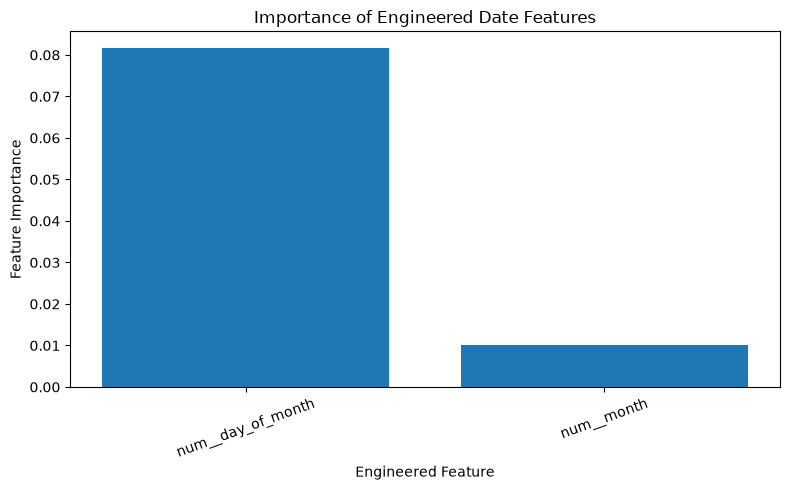

In [123]:
plt.figure(figsize=(8, 5))

plt.bar(
    engineered_features_importance["Feature"],
    engineered_features_importance["Importance"]
)

plt.xlabel("Engineered Feature")
plt.ylabel("Feature Importance")
plt.title("Importance of Engineered Date Features")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [127]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_eng = cross_validate(
    rf_pipeline_eng,
    X_train_eng,
    y_train_eng,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_rmse = -cv_results_eng["test_rmse"]
cv_mae = -cv_results_eng["test_mae"]
cv_r2 = cv_results_eng["test_r2"]

print("5-Fold Cross-Validation Results")
print("=" * 50)

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"RMSE = {cv_rmse[i]:.6f}, "
        f"MAE = {cv_mae[i]:.6f}, "
        f"R² = {cv_r2[i]:.6f}"
    )

5-Fold Cross-Validation Results
Fold 1: RMSE = 0.133823, MAE = 0.080713, R² = 0.469151
Fold 2: RMSE = 0.135278, MAE = 0.082704, R² = 0.367464
Fold 3: RMSE = 0.137829, MAE = 0.085282, R² = 0.404575
Fold 4: RMSE = 0.118343, MAE = 0.073436, R² = 0.504368
Fold 5: RMSE = 0.128098, MAE = 0.080381, R² = 0.504270


In [129]:
cv_rmse_mean = cv_rmse.mean()
cv_rmse_std = cv_rmse.std()

cv_mae_mean = cv_mae.mean()
cv_mae_std = cv_mae.std()

cv_r2_mean = cv_r2.mean()
cv_r2_std = cv_r2.std()

print("\nCross-Validation Summary")
print("=" * 50)

print(f"RMSE: {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}")
print(f"MAE : {cv_mae_mean:.6f} ± {cv_mae_std:.6f}")
print(f"R²  : {cv_r2_mean:.6f} ± {cv_r2_std:.6f}")


Cross-Validation Summary
RMSE: 0.130674 ± 0.006943
MAE : 0.080503 ± 0.003941
R²  : 0.449966 ± 0.055034


In [131]:
print("Final Test Set:")
print(f"RMSE = {final_rmse_eng:.6f}")
print(f"MAE  = {final_mae_eng:.6f}")
print(f"R²   = {final_r2_eng:.6f}")

print("\n5-Fold Cross-Validation:")
print(f"RMSE = {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}")
print(f"MAE  = {cv_mae_mean:.6f} ± {cv_mae_std:.6f}")
print(f"R²   = {cv_r2_mean:.6f} ± {cv_r2_std:.6f}")

cv_summary = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "CV Mean": [
        cv_rmse_mean,
        cv_mae_mean,
        cv_r2_mean
    ],
    "CV Std": [
        cv_rmse_std,
        cv_mae_std,
        cv_r2_std
    ],
    "Test Set": [
        final_rmse_eng,
        final_mae_eng,
        final_r2_eng
    ]
})

cv_summary

Final Test Set:
RMSE = 0.106486
MAE  = 0.068273
R²   = 0.572948

5-Fold Cross-Validation:
RMSE = 0.130674 ± 0.006943
MAE  = 0.080503 ± 0.003941
R²   = 0.449966 ± 0.055034


,Metric,CV Mean,CV Std,Test Set
0,RMSE,0.130674,0.006943,0.106486
1,MAE,0.080503,0.003941,0.068273
2,R2,0.449966,0.055034,0.572948


In [132]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_baseline = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

baseline_rmse = -cv_baseline["test_rmse"]
baseline_mae = -cv_baseline["test_mae"]
baseline_r2 = cv_baseline["test_r2"]

In [134]:
cv_engineered = cross_validate(
    rf_pipeline_eng,
    X_train_eng,
    y_train_eng,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

engineered_rmse = -cv_engineered["test_rmse"]
engineered_mae = -cv_engineered["test_mae"]
engineered_r2 = cv_engineered["test_r2"]

print("BASELINE RANDOM FOREST")
print("=" * 60)

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"RMSE = {baseline_rmse[i]:.6f}, "
        f"MAE = {baseline_mae[i]:.6f}, "
        f"R² = {baseline_r2[i]:.6f}"
    )

print("\nENGINEERED RANDOM FOREST")
print("=" * 60)

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"RMSE = {engineered_rmse[i]:.6f}, "
        f"MAE = {engineered_mae[i]:.6f}, "
        f"R² = {engineered_r2[i]:.6f}"
    )

BASELINE RANDOM FOREST
Fold 1: RMSE = 0.133282, MAE = 0.080694, R² = 0.473438
Fold 2: RMSE = 0.136068, MAE = 0.083211, R² = 0.360046
Fold 3: RMSE = 0.136402, MAE = 0.084552, R² = 0.416842
Fold 4: RMSE = 0.117746, MAE = 0.071627, R² = 0.509354
Fold 5: RMSE = 0.129681, MAE = 0.081182, R² = 0.491946

ENGINEERED RANDOM FOREST
Fold 1: RMSE = 0.133823, MAE = 0.080713, R² = 0.469151
Fold 2: RMSE = 0.135278, MAE = 0.082704, R² = 0.367464
Fold 3: RMSE = 0.137829, MAE = 0.085282, R² = 0.404575
Fold 4: RMSE = 0.118343, MAE = 0.073436, R² = 0.504368
Fold 5: RMSE = 0.128098, MAE = 0.080381, R² = 0.504270


In [135]:
comparison_cv = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Engineered Random Forest"
    ],
    "CV RMSE Mean": [
        baseline_rmse.mean(),
        engineered_rmse.mean()
    ],
    "CV RMSE Std": [
        baseline_rmse.std(),
        engineered_rmse.std()
    ],
    "CV MAE Mean": [
        baseline_mae.mean(),
        engineered_mae.mean()
    ],
    "CV MAE Std": [
        baseline_mae.std(),
        engineered_mae.std()
    ],
    "CV R2 Mean": [
        baseline_r2.mean(),
        engineered_r2.mean()
    ],
    "CV R2 Std": [
        baseline_r2.std(),
        engineered_r2.std()
    ]
})

comparison_cv

,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,Random Forest,0.130636,0.006882,0.080253,0.004532,0.450325,0.054813
1,Engineered Random Forest,0.130674,0.006943,0.080503,0.003941,0.449966,0.055034


In [140]:
rmse_improvement_cv = (
    (baseline_rmse.mean() - engineered_rmse.mean())
    / baseline_rmse.mean()
) * 100

mae_improvement_cv = (
    (baseline_mae.mean() - engineered_mae.mean())
    / baseline_mae.mean()
) * 100

r2_improvement_cv = (
    (engineered_r2.mean() - baseline_r2.mean())
    / abs(baseline_r2.mean())
) * 100

print(f"CV RMSE improvement: {rmse_improvement_cv:.2f}%")
print(f"CV MAE improvement : {mae_improvement_cv:.2f}%")
print(f"CV R² improvement  : {r2_improvement_cv:.2f}%")

CV RMSE improvement: -0.03%
CV MAE improvement : -0.31%
CV R² improvement  : -0.08%


In [141]:
print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['team',
                                                   'targeted_productivity',
                                                   'smv', 'wip', 'over_time',
                                                   'incentive', 'idle_time',
                                                   'idle_men',
                                                   'no_of_style_change',
                                                   'no_of_workers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f

In [142]:
rf_pipeline.named_steps['regressor'].get_params()
final_model = rf_pipeline

final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [143]:
import joblib

joblib.dump(
    final_model,
    "final_random_forest_model.joblib",
    compress=3
)

print("Model saved successfully.")

Model saved successfully.


In [144]:
import os

model_path = "final_random_forest_model.joblib"

print("File exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print(
        "File size:",
        round(os.path.getsize(model_path) / (1024 * 1024), 2),
        "MB"
    )

File exists: True
File size: 4.07 MB


In [145]:
loaded_model = joblib.load("final_random_forest_model.joblib")

print("Model loaded successfully.")
print(type(loaded_model))

Model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [146]:
final_test_predictions = final_model.predict(X_test)

print("Number of predictions:", len(final_test_predictions))
print("First 10 predictions:")
print(final_test_predictions[:10])

Number of predictions: 240
First 10 predictions:
[0.47650549 0.80009698 0.64454096 0.56002427 0.59815636 0.72370228
 0.58083321 0.53971467 0.62736813 0.74880946]


In [147]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

final_mse = mean_squared_error(
    y_test,
    final_test_predictions
)

final_rmse = np.sqrt(final_mse)

final_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

final_r2 = r2_score(
    y_test,
    final_test_predictions
)

print("FINAL RANDOM FOREST RESULTS")
print("-" * 45)
print(f"MSE  : {final_mse:.6f}")
print(f"RMSE : {final_rmse:.6f}")
print(f"MAE  : {final_mae:.6f}")
print(f"R²   : {final_r2:.6f}")

FINAL RANDOM FOREST RESULTS
---------------------------------------------
MSE  : 0.011775
RMSE : 0.108514
MAE  : 0.068484
R²   : 0.556528


In [148]:
final_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R2"
    ],
    "Value": [
        final_mse,
        final_rmse,
        final_mae,
        final_r2
    ]
})

final_results

,Metric,Value
0,MSE,0.011775
1,RMSE,0.108514
2,MAE,0.068484
3,R2,0.556528


In [149]:
evaluation_summary = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "5-Fold CV Mean": [
        baseline_rmse.mean(),
        baseline_mae.mean(),
        baseline_r2.mean()
    ],
    "5-Fold CV Std": [
        baseline_rmse.std(),
        baseline_mae.std(),
        baseline_r2.std()
    ],
    "Test Set": [
        final_rmse,
        final_mae,
        final_r2
    ]
})

evaluation_summary

,Metric,5-Fold CV Mean,5-Fold CV Std,Test Set
0,RMSE,0.130636,0.006882,0.108514
1,MAE,0.080253,0.004532,0.068484
2,R2,0.450325,0.054813,0.556528


In [150]:
final_residuals = y_test - final_test_predictions

print("Final residual statistics")
print("-" * 40)
print("Mean residual:", final_residuals.mean())
print("Minimum residual:", final_residuals.min())
print("Maximum residual:", final_residuals.max())

Final residual statistics
----------------------------------------
Mean residual: 0.01131848348660389
Minimum residual: -0.5420810839949993
Maximum residual: 0.42320393463499945


In [151]:
final_error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_test_predictions,
    "Residual": final_residuals.values
})

final_error_analysis["Absolute_Error"] = (
    final_error_analysis["Residual"].abs()
)

final_largest_errors = (
    final_error_analysis
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .reset_index(drop=True)
)

final_largest_errors.head(10)

,Actual,Predicted,Residual,Absolute_Error
0,0.287042,0.829123,-0.542081,0.542081
1,0.831937,0.408734,0.423204,0.423204
2,0.313853,0.700242,-0.386389,0.386389
3,0.537500,0.885824,-0.348324,0.348324
4,0.280333,0.592465,-0.312132,0.312132
5,0.950625,0.646858,0.303767,0.303767
6,0.994375,0.724553,0.269822,0.269822
7,0.495417,0.740718,-0.245302,0.245302
8,0.408960,0.650153,-0.241192,0.241192
9,0.325000,0.560024,-0.235024,0.235024


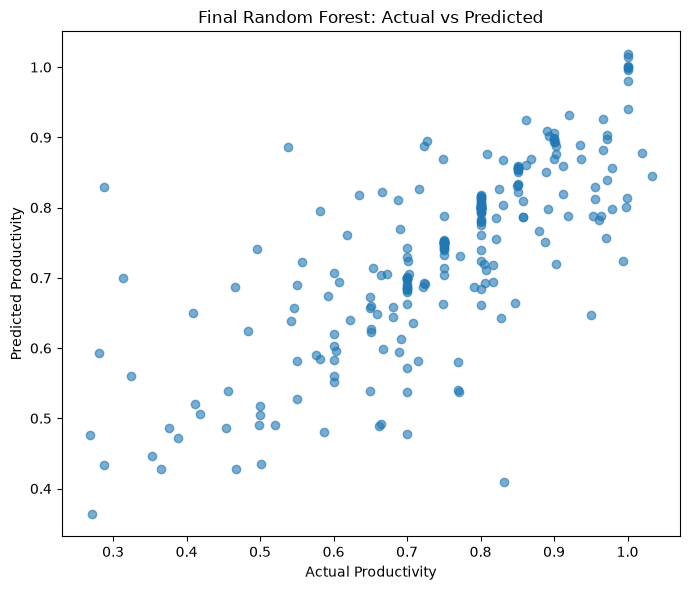

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    final_test_predictions,
    alpha=0.6
)

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Final Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()

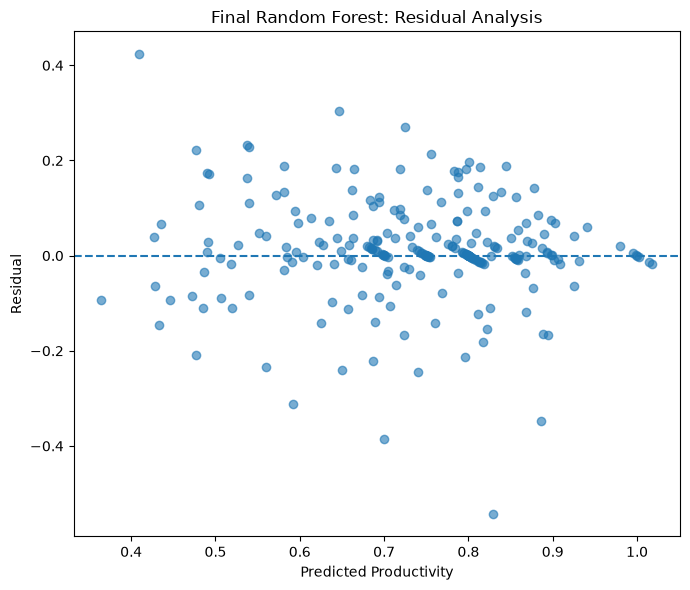

In [153]:
plt.figure(figsize=(7, 6))

plt.scatter(
    final_test_predictions,
    final_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Productivity")
plt.ylabel("Residual")
plt.title("Final Random Forest: Residual Analysis")

plt.tight_layout()
plt.show()

In [154]:
final_rf = final_model.named_steps["regressor"]

print(final_rf)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)


In [155]:
final_feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of transformed features:", len(final_feature_names))
print(final_feature_names)

Number of transformed features: 24
['num__team' 'num__targeted_productivity' 'num__smv' 'num__wip'
 'num__over_time' 'num__incentive' 'num__idle_time' 'num__idle_men'
 'num__no_of_style_change' 'num__no_of_workers' 'cat__quarter_Quarter1'
 'cat__quarter_Quarter2' 'cat__quarter_Quarter3' 'cat__quarter_Quarter4'
 'cat__quarter_Quarter5' 'cat__department_finishing'
 'cat__department_finishing ' 'cat__department_sweing' 'cat__day_Monday'
 'cat__day_Saturday' 'cat__day_Sunday' 'cat__day_Thursday'
 'cat__day_Tuesday' 'cat__day_Wednesday']


In [157]:
final_importances = final_rf.feature_importances_

print("Number of importances:", len(final_importances))

print(
    len(final_feature_names),
    len(final_importances)
)

Number of importances: 24
24 24


In [158]:
final_feature_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_importances
})

final_feature_importance = (
    final_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

final_feature_importance["Rank"] = (
    final_feature_importance.index + 1
)

final_feature_importance.head(15)

,Feature,Importance,Rank
0,num__targeted_productivity,0.237472,1
1,num__smv,0.110705,2
2,num__incentive,0.099566,3
3,num__team,0.098260,4
4,num__no_of_workers,0.093322,5
5,num__over_time,0.080566,6
6,num__wip,0.035672,7
7,cat__quarter_Quarter4,0.029802,8
8,cat__department_finishing,0.028259,9
9,cat__day_Wednesday,0.019748,10


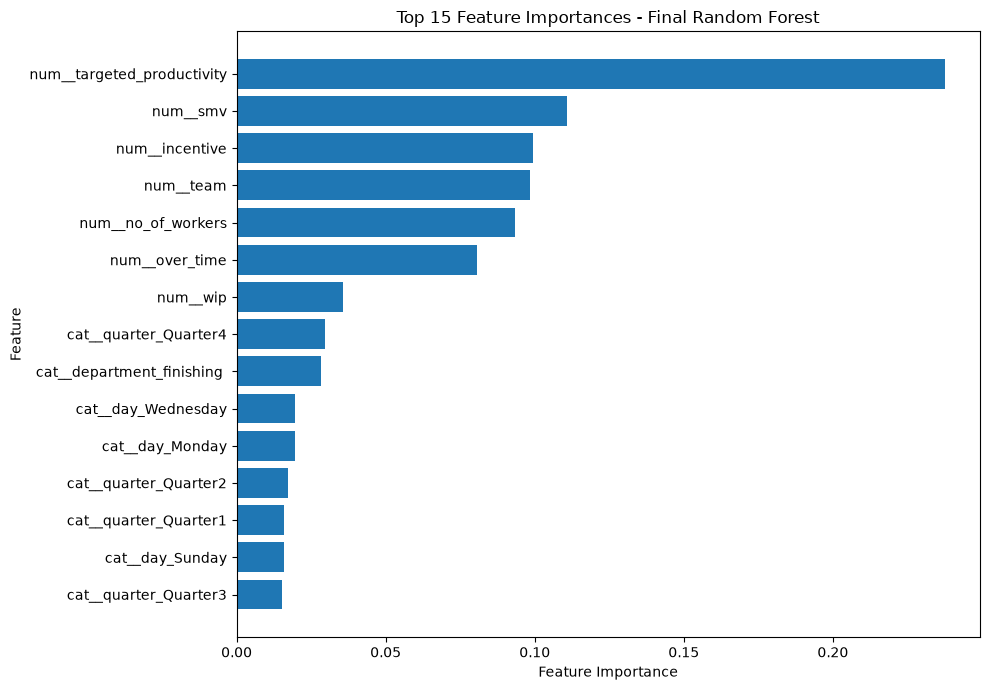

In [159]:
top_15_final = (
    final_feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15_final["Feature"],
    top_15_final["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Final Random Forest")

plt.tight_layout()
plt.show()

In [161]:
final_feature_importance.to_csv(
    "final_random_forest_feature_importance.csv",
    index=False
)

print("Final feature-importance table saved.")

final_top10 = final_feature_importance.head(10)

final_top10

final_feature_importance.head(15)

Final feature-importance table saved.


,Feature,Importance,Rank
0,num__targeted_productivity,0.237472,1
1,num__smv,0.110705,2
2,num__incentive,0.099566,3
3,num__team,0.098260,4
4,num__no_of_workers,0.093322,5
5,num__over_time,0.080566,6
6,num__wip,0.035672,7
7,cat__quarter_Quarter4,0.029802,8
8,cat__department_finishing,0.028259,9
9,cat__day_Wednesday,0.019748,10


In [162]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Boosting",
        "Extra Trees",
        "Random Forest",
        "Engineered Random Forest"
    ],
    "MSE": [
        0.0227974398,
        0.0147053466,
        0.0150984515,
        0.011775,
        0.0113392904
    ],
    "RMSE": [
        0.1509882108,
        0.1212656034,
        0.1228757563,
        0.108514,
        0.1064861041
    ],
    "MAE": [
        0.1124643720,
        0.0788220403,
        0.0791242434,
        0.068484,
        0.0682732967
    ],
    "R2": [
        0.1414191298,
        0.4461777574,
        0.4313729209,
        0.556528,
        0.5729477576
    ]
})

final_model_comparison

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.022797,0.150988,0.112464,0.141419
1,Gradient Boosting,0.014705,0.121266,0.078822,0.446178
2,Extra Trees,0.015098,0.122876,0.079124,0.431373
3,Random Forest,0.011775,0.108514,0.068484,0.556528
4,Engineered Random Forest,0.011339,0.106486,0.068273,0.572948


In [163]:
cv_final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Engineered Random Forest"
    ],
    "CV RMSE Mean": [
        baseline_rmse.mean(),
        engineered_rmse.mean()
    ],
    "CV RMSE Std": [
        baseline_rmse.std(),
        engineered_rmse.std()
    ],
    "CV MAE Mean": [
        baseline_mae.mean(),
        engineered_mae.mean()
    ],
    "CV MAE Std": [
        baseline_mae.std(),
        engineered_mae.std()
    ],
    "CV R2 Mean": [
        baseline_r2.mean(),
        engineered_r2.mean()
    ],
    "CV R2 Std": [
        baseline_r2.std(),
        engineered_r2.std()
    ]
})

cv_final_comparison

,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,Random Forest,0.130636,0.006882,0.080253,0.004532,0.450325,0.054813
1,Engineered Random Forest,0.130674,0.006943,0.080503,0.003941,0.449966,0.055034


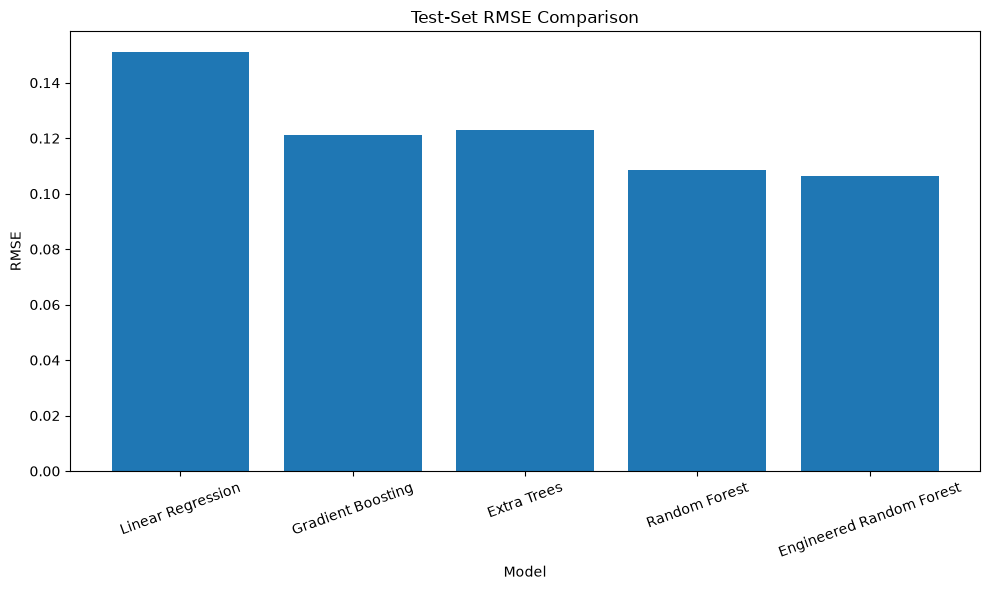

In [164]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Test-Set RMSE Comparison")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

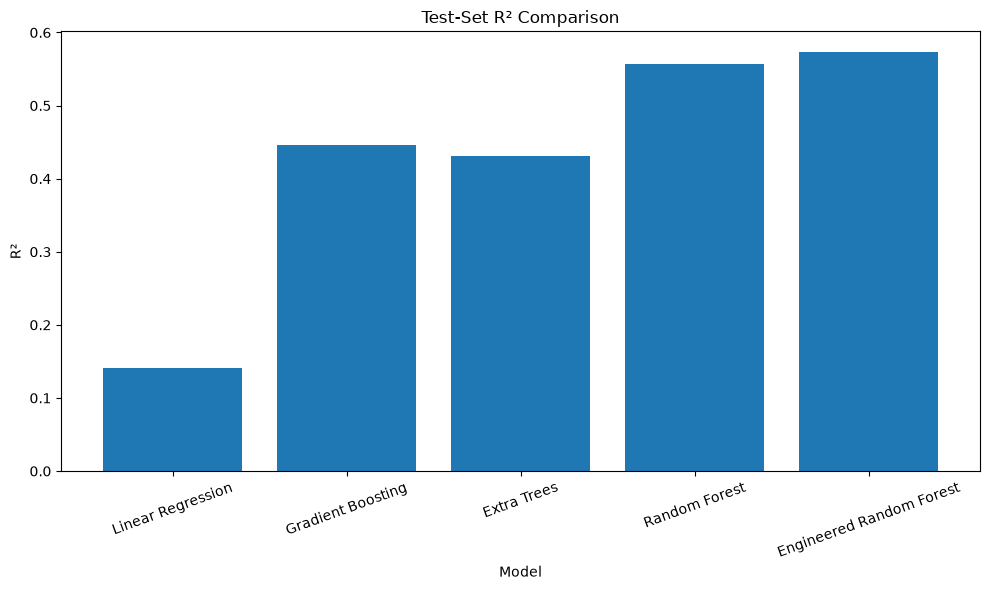

In [165]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["R2"]
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Test-Set R² Comparison")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [166]:
final_model_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

cv_final_comparison.to_csv(
    "cross_validation_model_comparison.csv",
    index=False
)

print("Final comparison tables saved successfully.")

Final comparison tables saved successfully.


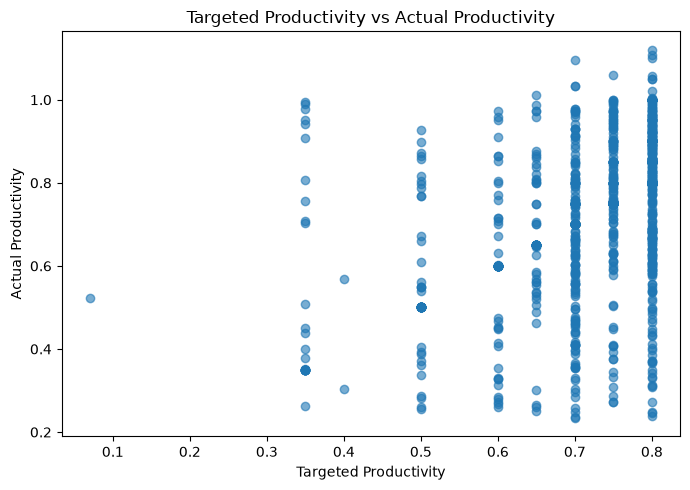

In [167]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["targeted_productivity"],
    df["actual_productivity"],
    alpha=0.6
)

plt.xlabel("Targeted Productivity")
plt.ylabel("Actual Productivity")
plt.title(
    "Targeted Productivity vs Actual Productivity"
)

plt.tight_layout()
plt.show()

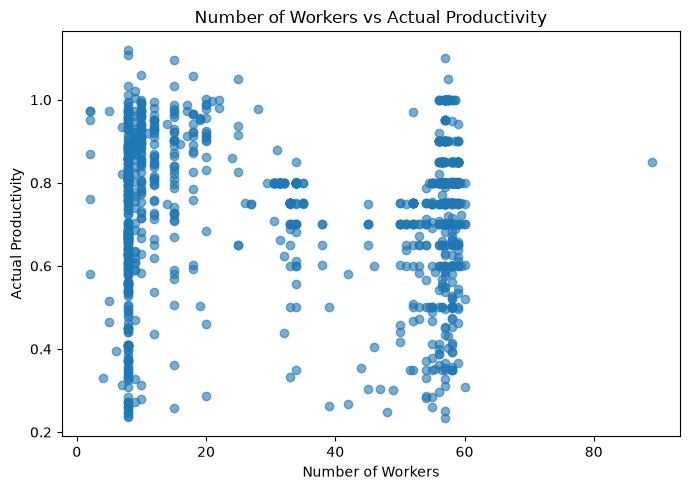

In [168]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["no_of_workers"],
    df["actual_productivity"],
    alpha=0.6
)

plt.xlabel("Number of Workers")
plt.ylabel("Actual Productivity")
plt.title(
    "Number of Workers vs Actual Productivity"
)

plt.tight_layout()
plt.show()

In [171]:
print("Unique months:")
print(sorted(df["month"].dropna().unique()))

print("\nDay-of-month range:")
print(
    df["day_of_month"].min(),
    "to",
    df["day_of_month"].max()
)

Unique months:
[np.int32(1), np.int32(2), np.int32(3)]

Day-of-month range:
1 to 31
